# Visual report generation

In [3]:
import pandas as pd

# Load a sample dataset
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')


# NA analysis

In [43]:
df.isna().sum()
df1 = df.copy()
df2 = df1.ffill().fillna(0)
df2.isna().sum()
df1.iloc[5]

# Filter all rows where Age is Nan
df1[df1['Age'].isna()]
df2.iloc[5]

PassengerId                   6
Survived                      0
Pclass                        3
Name           Moran, Mr. James
Sex                        male
Age                        35.0
SibSp                         0
Parch                         0
Ticket                   330877
Fare                     8.4583
Cabin                      C123
Embarked                      Q
Name: 5, dtype: object

## Data generation

In [4]:
import pandas as pd
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns # For creating initial data for a scenario

# Set a random seed for reproducibility
np.random.seed(42)

# --- Scenario 1: Missing At Random (MAR) ---
# Example: 'Income' is more likely to be missing for individuals with 'Low Education'

# Create a base DataFrame
n_samples = 200
data = {
    'Age': np.random.randint(20, 60, n_samples),
    'Education_Level': np.random.choice(['High', 'Medium', 'Low'], n_samples, p=[0.3, 0.4, 0.3]),
    'Monthly_Income': np.random.normal(5000, 1500, n_samples).round(0),
    'Years_Experience': np.random.randint(1, 30, n_samples)
}
df_mar = pd.DataFrame(data)

# Introduce MAR missingness: Income is missing if Education_Level is 'Low'
# and sometimes missing for 'Medium' education as well.
# This makes it dependent on an OBSERVED variable (Education_Level).
df_mar.loc[df_mar['Education_Level'] == 'Low', 'Monthly_Income'] = np.nan
df_mar.loc[df_mar['Education_Level'] == 'Medium', 'Monthly_Income'] = df_mar.loc[df_mar['Education_Level'] == 'Medium', 'Monthly_Income'].apply(
    lambda x: np.nan if np.random.rand() < 0.3 else x # 30% missing for Medium Education
)

# Introduce some random missingness in 'Years_Experience' (closer to MCAR for this column)
df_mar.loc[np.random.rand(n_samples) < 0.1, 'Years_Experience'] = np.nan

# --- Scenario 2: Closer to MNAR (Missing Not At Random) ---
# Example: 'Customer_Satisfaction' (on a scale 1-10) is missing if the actual
# satisfaction is very low (e.g., < 4) or very high (e.g., > 8)

n_samples_mnar = 150
data_mnar = {
    'Purchase_Amount': np.random.normal(100, 30, n_samples_mnar).round(2),
    'Customer_Satisfaction': np.random.randint(1, 11, n_samples_mnar), # True satisfaction
    'Support_Calls': np.random.randint(0, 5, n_samples_mnar)
}
df_mnar = pd.DataFrame(data_mnar)

# Introduce MNAR missingness: Customer_Satisfaction is missing if it's very low or very high
# This makes it dependent on the UNBSERVED value of Customer_Satisfaction itself.
df_mnar.loc[(df_mnar['Customer_Satisfaction'] < 4) | (df_mnar['Customer_Satisfaction'] > 8), 'Customer_Satisfaction'] = np.nan

# Add some MCAR-like missingness to Purchase_Amount
df_mnar.loc[np.random.rand(n_samples_mnar) < 0.05, 'Purchase_Amount'] = np.nan

# Display first few rows and info for a quick check
print("--- df_mar info ---")
df_mar.info()
print("\n--- df_mnar info ---")
df_mnar.info()

--- df_mar info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               200 non-null    int64  
 1   Education_Level   200 non-null    object 
 2   Monthly_Income    124 non-null    float64
 3   Years_Experience  175 non-null    float64
dtypes: float64(2), int64(1), object(1)
memory usage: 6.4+ KB

--- df_mnar info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 3 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Purchase_Amount        144 non-null    float64
 1   Customer_Satisfaction  72 non-null     float64
 2   Support_Calls          150 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 3.6 KB


## NA analysis approach with Missingno

How to use these in practice:

- Start with msno.matrix() and msno.bar(): Get a quick visual sense of where NAs are and how prevalent they are.
Move to msno.heatmap() and msno.dendrogram(): These are key for discovering systematic relationships between missingness across different columns.
- If X and Y both have NAs, and their missingness correlation is high in the heatmap, it suggests that if X is missing, Y is also likely missing (or vice-versa). This points towards a common underlying reason for missingness, which is a strong indicator of MAR.
- If columns cluster tightly in the dendrogram, their missingness patterns are very similar.
Combine with Domain Knowledge: The visuals will give you clues, but your understanding of the data collection process and the real-world meaning of the variables is crucial for hypothesizing the actual missingness mechanism (MCAR, MAR, or MNAR). For instance, if msno.heatmap shows no correlation in missingness, it might suggest MCAR. If it shows high correlation between Income and Job_Title missingness, it suggests MAR (e.g., people in certain jobs are less likely to report income). If no strong patterns emerge between missingness of different variables, and you suspect the missing variable's own value is the cause, then MNAR might be at play.

<Figure size 600x600 with 0 Axes>

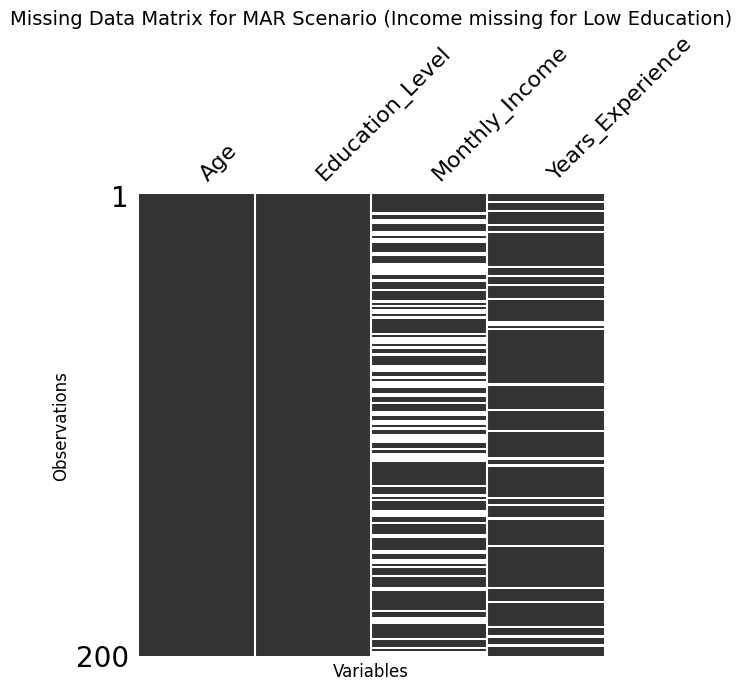

In [8]:
# --- msno.matrix() for df_mar (MAR example) ---
plt.figure(figsize=(6, 6))
msno.matrix(df_mar, figsize=(6, 6), color=(0.2, 0.2, 0.2), sparkline=False)
plt.title('Missing Data Matrix for MAR Scenario (Income missing for Low Education)', fontsize=14)
plt.xlabel('Variables', fontsize=12)
plt.ylabel('Observations', fontsize=12)
plt.show()

<Figure size 600x600 with 0 Axes>

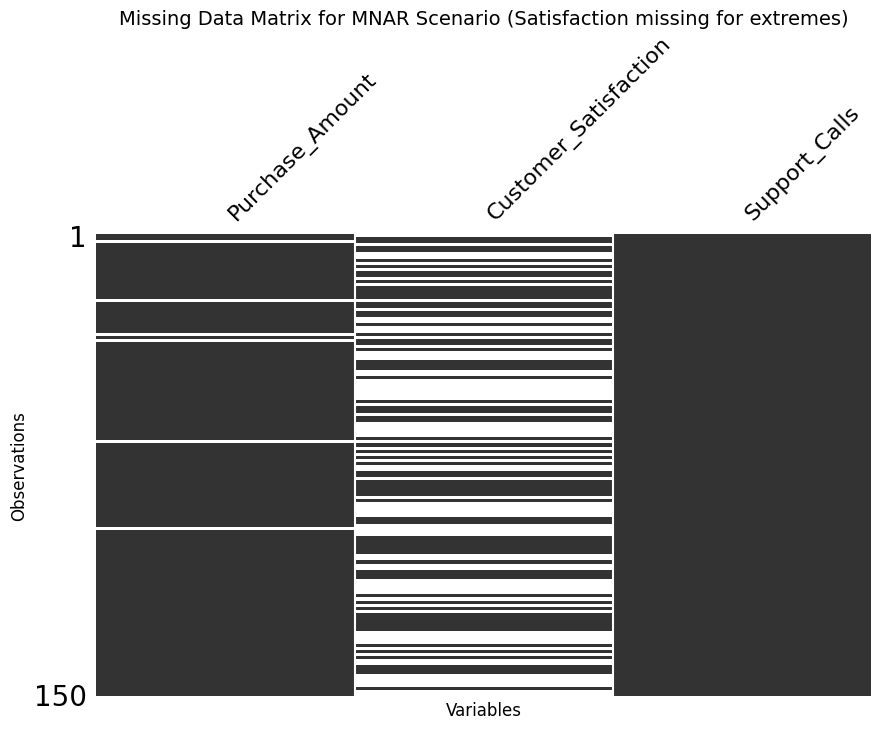

In [9]:
# --- msno.matrix() for df_mnar (MNAR example) ---
plt.figure(figsize=(6, 6))
msno.matrix(df_mnar, figsize=(10, 6), color=(0.2, 0.2, 0.2), sparkline=False)
plt.title('Missing Data Matrix for MNAR Scenario (Satisfaction missing for extremes)', fontsize=14)
plt.xlabel('Variables', fontsize=12)
plt.ylabel('Observations', fontsize=12)
plt.show()

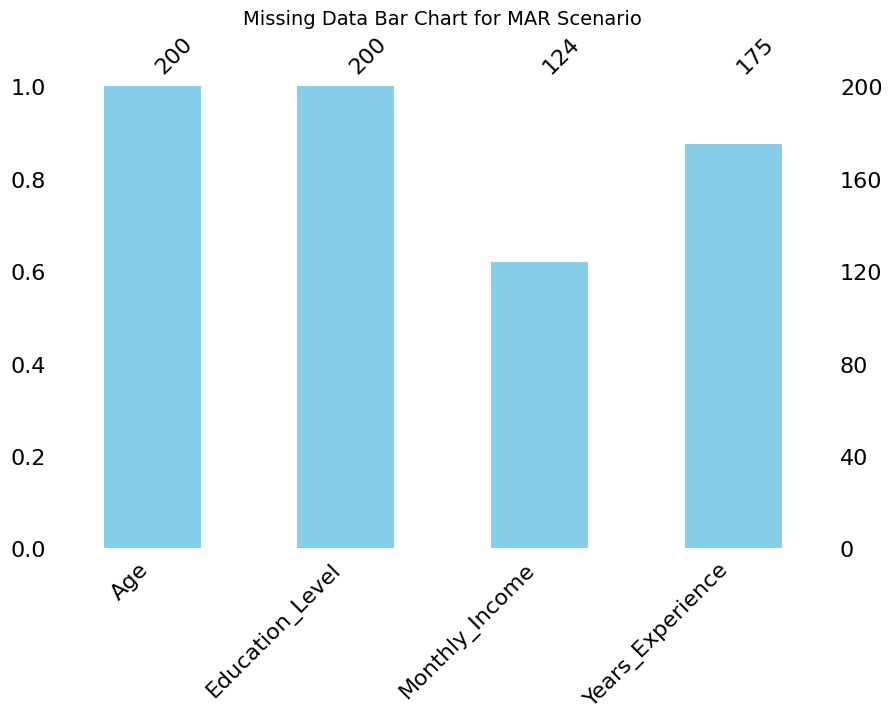

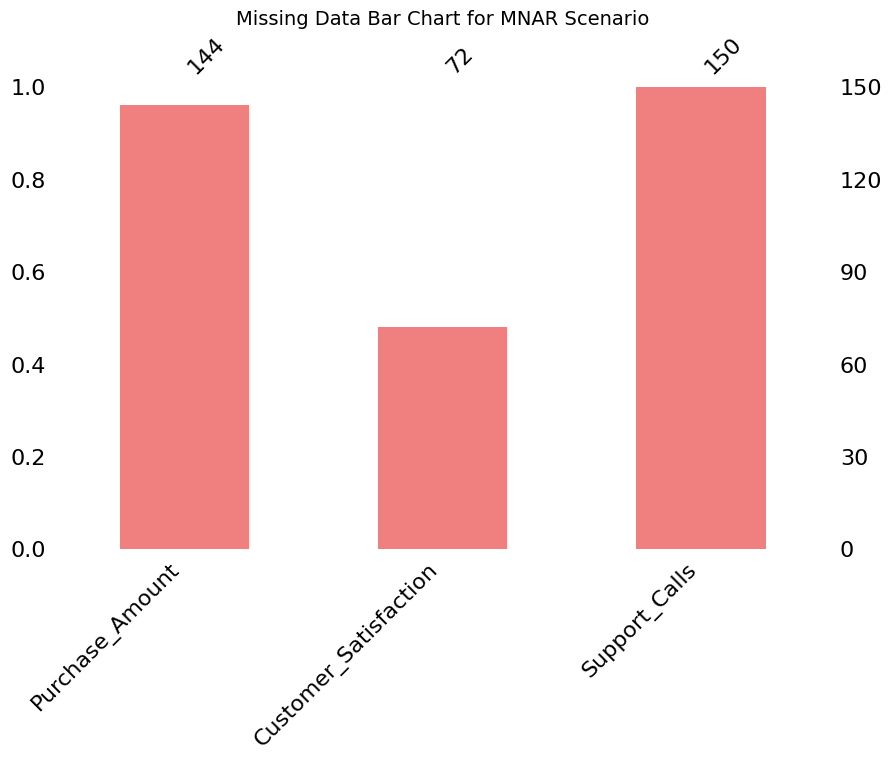

In [10]:
# --- msno.bar() for df_mar ---
plt.figure(figsize=(10, 6))
msno.bar(df_mar, color='skyblue', figsize=(10, 6))
plt.title('Missing Data Bar Chart for MAR Scenario', fontsize=14)
plt.show()

# --- msno.bar() for df_mnar ---
plt.figure(figsize=(10, 6))
msno.bar(df_mnar, color='lightcoral', figsize=(10, 6))
plt.title('Missing Data Bar Chart for MNAR Scenario', fontsize=14)
plt.show()

<Figure size 800x700 with 0 Axes>

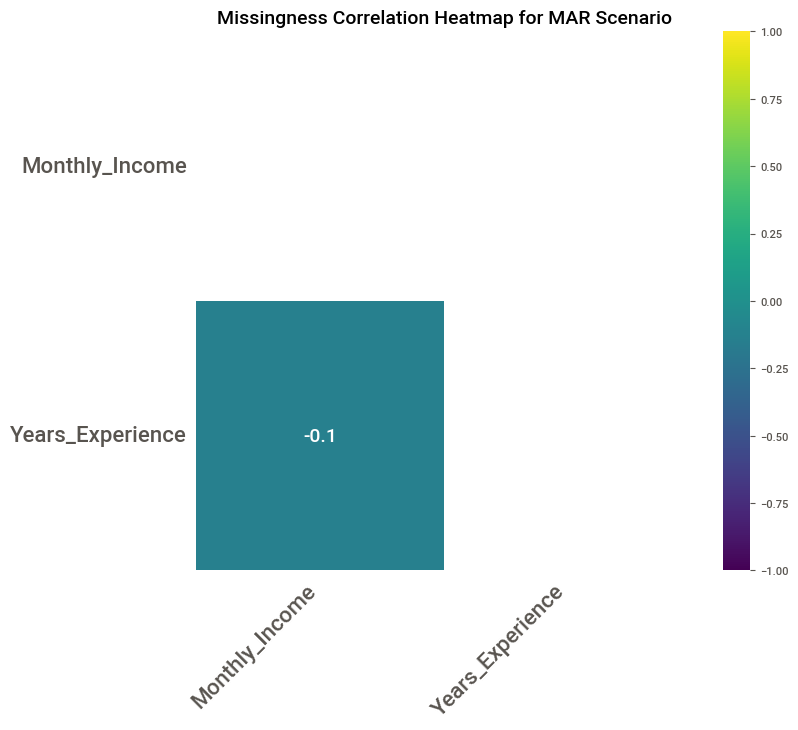

<Figure size 800x700 with 0 Axes>

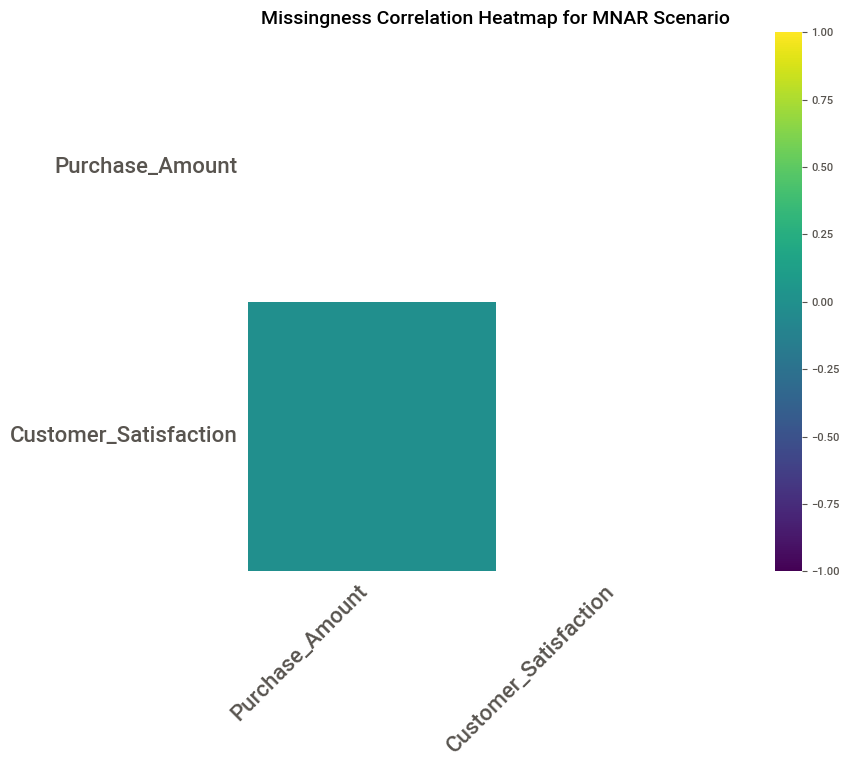

In [ ]:
# --- msno.heatmap() for df_mar (MAR example) ---
plt.figure(figsize=(8, 7))
msno.heatmap(df_mar, figsize=(8, 7), cmap='viridis')
plt.title('Missingness Correlation Heatmap for MAR Scenario', fontsize=14)
plt.show()

# --- msno.heatmap() for df_mnar (MNAR example) ---
plt.figure(figsize=(8, 7))
msno.heatmap(df_mnar, figsize=(8, 7), cmap='viridis')
plt.title('Missingness Correlation Heatmap for MNAR Scenario', fontsize=14)
plt.show()

<Figure size 1000x700 with 0 Axes>

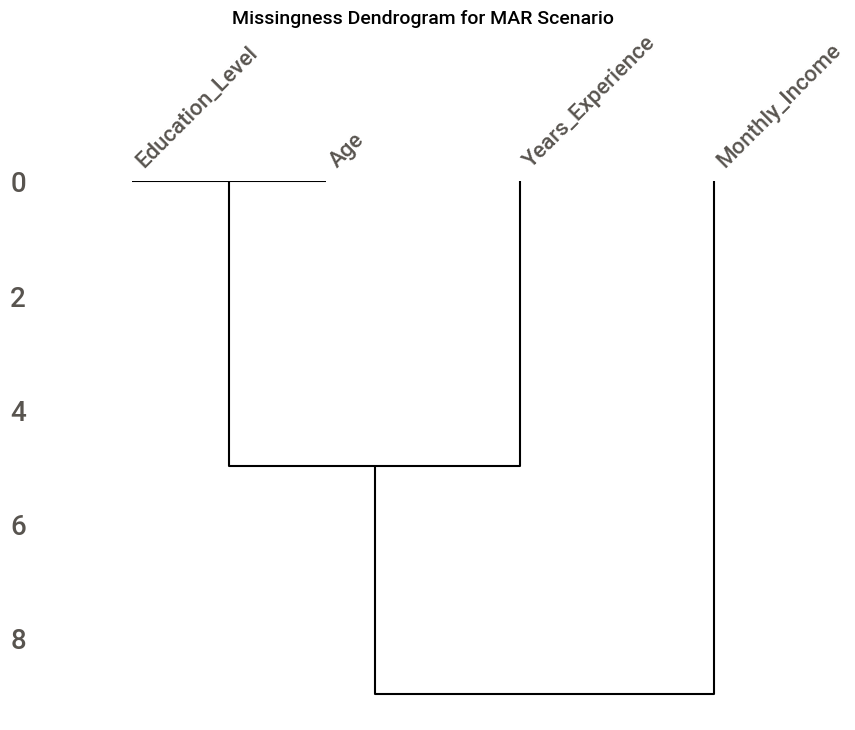

<Figure size 1000x700 with 0 Axes>

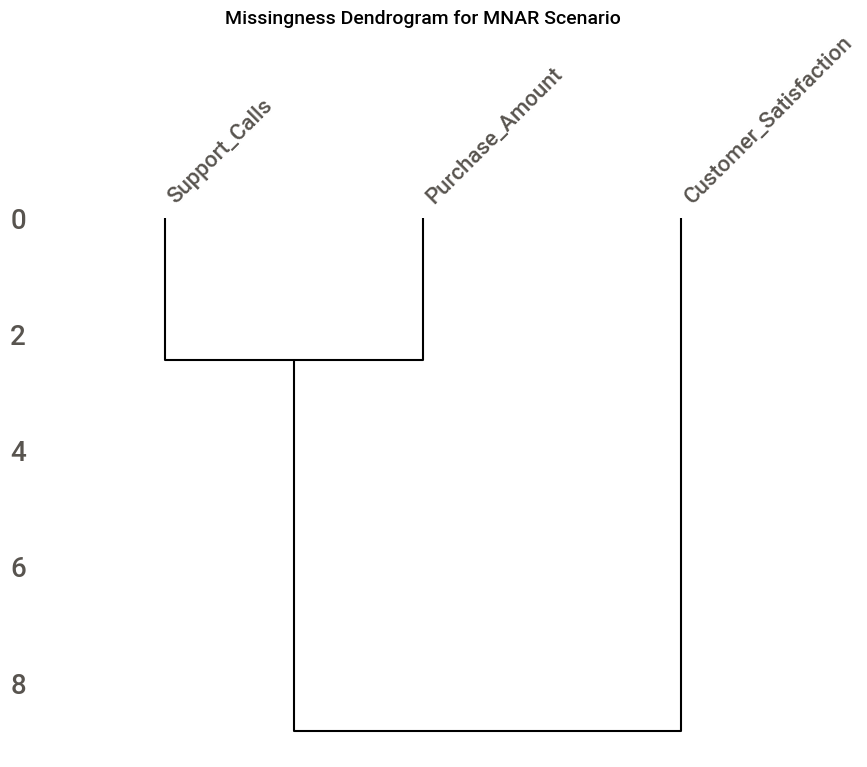

In [ ]:
# --- msno.dendrogram() for df_mar (MAR example) ---
plt.figure(figsize=(10, 7))
msno.dendrogram(df_mar, figsize=(10, 7))
plt.title('Missingness Dendrogram for MAR Scenario', fontsize=14)
plt.show()

# --- msno.dendrogram() for df_mnar (MNAR example) ---
plt.figure(figsize=(10, 7))
msno.dendrogram(df_mnar, figsize=(10, 7))
plt.title('Missingness Dendrogram for MNAR Scenario', fontsize=14)
plt.show()